# 2-dars: Regression Modellar

## 📚 Dars maqsadi
Ushbu darsda biz regression modellarining barcha asosiy turlarini o'rganamiz:
- Linear Regression (Chiziqli Regressiya)
- Polynomial Regression (Ko'phadli Regressiya)
- Regularization: Ridge va Lasso Regression

---

In [1]:
# Kerakli kutubxonalarni import qilish
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Vizualizatsiya sozlamalari
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

---

# 1️⃣ Linear Regression (Chiziqli Regressiya)

## 📖 Nazariya

Linear Regression - bu eng sodda va keng tarqalgan regression usuli. U kirish o'zgaruvchilari (features) va chiqish o'zgaruvchisi (target) o'rtasida **chiziqli munosabat** borligini taxmin qiladi.

### 📐 Matematika

**Simple Linear Regression** (1 feature):
$$y = \beta_0 + \beta_1 x + \epsilon$$

**Multiple Linear Regression** (ko'p feature'lar):
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

Bu yerda:
- $y$ - bashorat qilinadigan qiymat (target)
- $x_1, x_2, ..., x_n$ - kirish o'zgaruvchilari (features)
- $\beta_0$ - y-kesim (intercept)
- $\beta_1, ..., \beta_n$ - koeffitsientlar (slopes)
- $\epsilon$ - xatolik (error)

### 🎯 Maqsad: Cost Function ni minimallashtirish

**Mean Squared Error (MSE)**:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Bu yerda:
- $y_i$ - haqiqiy qiymat
- $\hat{y}_i$ - bashorat qilingan qiymat
- $n$ - namunalar soni

## 💡 Misol 1: Simple Linear Regression

Keling, oddiy misol ko'raylik: ish tajribasi va maosh o'rtasidagi bog'liqlik.

In [2]:
# Ma'lumotlar yaratish
np.random.seed(42)
experience = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
salary = 30000 + 5000 * experience.flatten() + np.random.normal(0, 2000, 10)

# DataFrame yaratish
df = pd.DataFrame({'Experience': experience.flatten(), 'Salary': salary})
print("Ma'lumotlar:")
print(df)
print(f"\nO'rtacha maosh: ${salary.mean():.2f}")
print(f"Minimal maosh: ${salary.min():.2f}")
print(f"Maksimal maosh: ${salary.max():.2f}")

Ma'lumotlar:
   Experience        Salary
0           1  35993.428306
1           2  39723.471398
2           3  46295.377076
3           4  53046.059713
4           5  54531.693251
5           6  59531.726086
6           7  68158.425631
7           8  71534.869458
8           9  74061.051228
9          10  81085.120087

O'rtacha maosh: $58396.12
Minimal maosh: $35993.43
Maksimal maosh: $81085.12


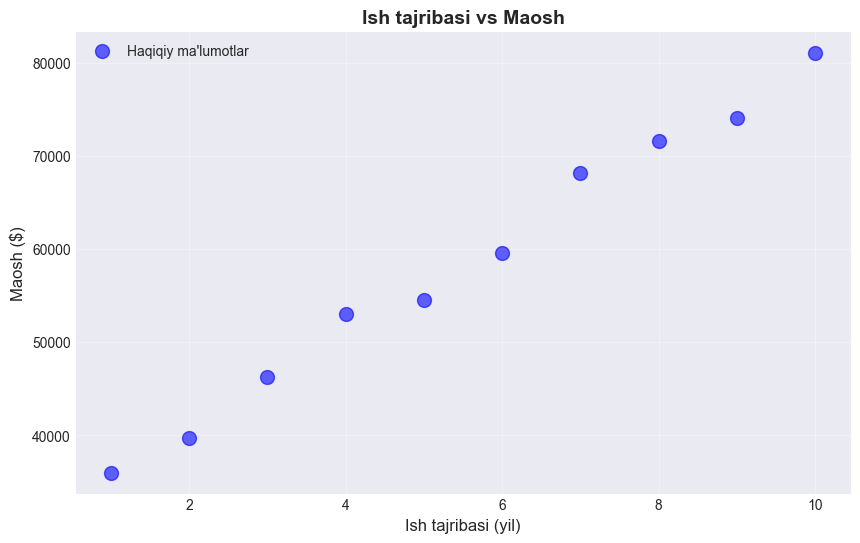

In [3]:
# Vizualizatsiya
plt.figure(figsize=(10, 6))
plt.scatter(experience, salary, color='blue', s=100, alpha=0.6, label='Haqiqiy ma\'lumotlar')
plt.xlabel('Ish tajribasi (yil)', fontsize=12)
plt.ylabel('Maosh ($)', fontsize=12)
plt.title('Ish tajribasi vs Maosh', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Model yaratish va o'rgatish
model = LinearRegression()
model.fit(experience, salary)

# Model parametrlari
print("Model parametrlari:")
print(f"Intercept (β₀): ${model.intercept_:.2f}")
print(f"Coefficient (β₁): ${model.coef_[0]:.2f}")
print(f"\nTenglik: Salary = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Experience")

Model parametrlari:
Intercept (β₀): $30972.03
Coefficient (β₁): $4986.20

Tenglik: Salary = 30972.03 + 4986.20 × Experience


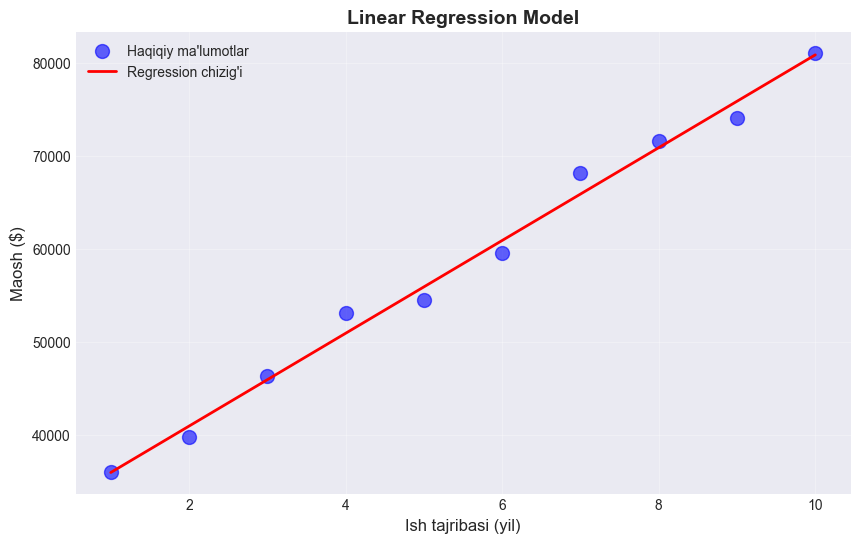

In [5]:
# Bashorat qilish
predictions = model.predict(experience)

# Vizualizatsiya - Model bilan
plt.figure(figsize=(10, 6))
plt.scatter(experience, salary, color='blue', s=100, alpha=0.6, label='Haqiqiy ma\'lumotlar')
plt.plot(experience, predictions, color='red', linewidth=2, label='Regression chizig\'i')
plt.xlabel('Ish tajribasi (yil)', fontsize=12)
plt.ylabel('Maosh ($)', fontsize=12)
plt.title('Linear Regression Model', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Model baholash
r2 = r2_score(salary, predictions) # determinatsiya koeffitsienti
mse = mean_squared_error(salary, predictions) # o'rtacha kvadrat xato - kvadratik xatolik
rmse = np.sqrt(mse) # ildiz ostidagi o'rtacha kvadrat xato - o'rtacha xatolik
mae = mean_absolute_error(salary, predictions) # o'rtacha mutlaq xato 

print("Model baholash metrikasi:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: ${mse:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"\nIzoh: R² = {r2:.2%} - model variatsiyasini tushuntiradi")

Model baholash metrikasi:
R² Score: 0.9909
MSE: $1880296.48
RMSE: $1371.24
MAE: $1147.31

Izoh: R² = 99.09% - model variatsiyasini tushuntiradi


In [7]:
# Yangi bashorat
new_experience = np.array([[15], [20]])
new_predictions = model.predict(new_experience)

print("Yangi bashoratlar:")
for exp, pred in zip(new_experience.flatten(), new_predictions):
    print(f"{exp} yillik tajriba uchun bashorat: ${pred:.2f}")

Yangi bashoratlar:
15 yillik tajriba uchun bashorat: $105765.02
20 yillik tajriba uchun bashorat: $130696.01


## 💡 Misol 2: Multiple Linear Regression

Endi ko'p feature'lar bilan ishlashni ko'raylik: uy narxini bashorat qilish.

In [8]:
# Ko'p o'zgaruvchilar bilan ma'lumotlar yaratish
np.random.seed(42)
n_samples = 100

house_data = pd.DataFrame({
    'Area': np.random.randint(500, 3000, n_samples),  # kvadrat metr
    'Bedrooms': np.random.randint(1, 6, n_samples),   # xonalar soni
    'Age': np.random.randint(0, 50, n_samples),       # bino yoshi
    'Location_Score': np.random.randint(1, 11, n_samples)  # joylashuv balli (1-10)
})

# Narxni hisoblash (taxminiy formula)
house_data['Price'] = (
    50000 + 
    200 * house_data['Area'] + 
    10000 * house_data['Bedrooms'] - 
    1000 * house_data['Age'] + 
    15000 * house_data['Location_Score'] +
    np.random.normal(0, 20000, n_samples)
)

print("Uy ma'lumotlari:")
print(house_data.head(10))
print(f"\nMa'lumotlar shakli: {house_data.shape}")
print(f"\nStatistika:")
print(house_data.describe())

Uy ma'lumotlari:
   Area  Bedrooms  Age  Location_Score          Price
0  1360         2    8               1  333563.618445
1  1794         1    5               1  462026.034612
2  1630         5   15               5  479315.058177
3  1595         3   28               3  409643.061870
4  2138         4    2               4  581955.340649
5  2669         3   19               3  607555.453857
6   966         3   35               1  272107.633802
7  1738         1   18               1  429928.137107
8   830         3   25               5  303545.925309
9  1982         5    2               6  617427.019730

Ma'lumotlar shakli: (100, 5)

Statistika:
              Area    Bedrooms         Age  Location_Score          Price
count   100.000000  100.000000  100.000000      100.000000     100.000000
mean   1803.240000    2.900000   24.570000        5.480000  500047.295458
std     721.603827    1.431958   14.089365        3.040069  152693.064961
min     521.000000    1.000000    0.000000        

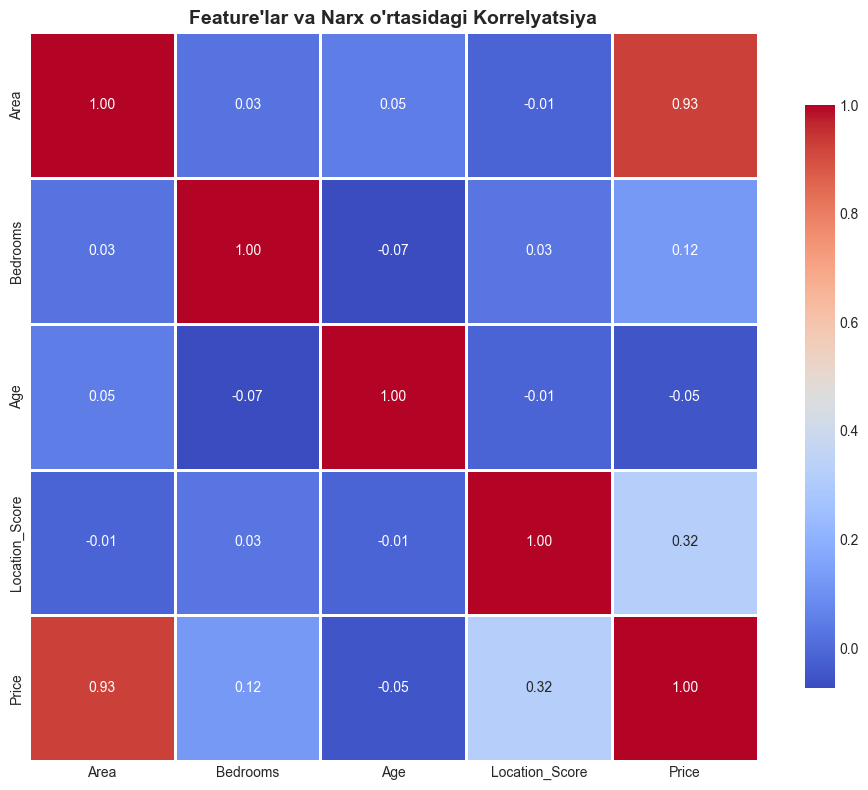

In [9]:
# Korrelyatsiya matritsasi
plt.figure(figsize=(10, 8))
correlation_matrix = house_data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature\'lar va Narx o\'rtasidagi Korrelyatsiya', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Ma'lumotlarni ajratish
X = house_data[['Area', 'Bedrooms', 'Age', 'Location_Score']]
y = house_data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (80, 4)
Test set: (20, 4)


In [11]:
# Multiple Linear Regression modeli
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# Koeffitsientlarni ko'rish
print("Model koeffitsientlari:")
print(f"Intercept: ${mlr_model.intercept_:.2f}")
print("\nFeature koeffitsientlari:")
for feature, coef in zip(X.columns, mlr_model.coef_):
    print(f"  {feature}: ${coef:.2f}")

Model koeffitsientlari:
Intercept: $54591.95

Feature koeffitsientlari:
  Area: $196.85
  Bedrooms: $8544.75
  Age: $-916.98
  Location_Score: $16145.86


In [12]:
# Bashorat va baholash
y_train_pred = mlr_model.predict(X_train)
y_test_pred = mlr_model.predict(X_test)

# Train metrikasi
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test metrikasi
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("TRAIN SET:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: ${train_rmse:.2f}")
print(f"  MAE: ${train_mae:.2f}")

print("\nTEST SET:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: ${test_rmse:.2f}")
print(f"  MAE: ${test_mae:.2f}")

TRAIN SET:
  R² Score: 0.9811
  RMSE: $20502.45
  MAE: $16936.48

TEST SET:
  R² Score: 0.9885
  RMSE: $17422.51
  MAE: $14673.37


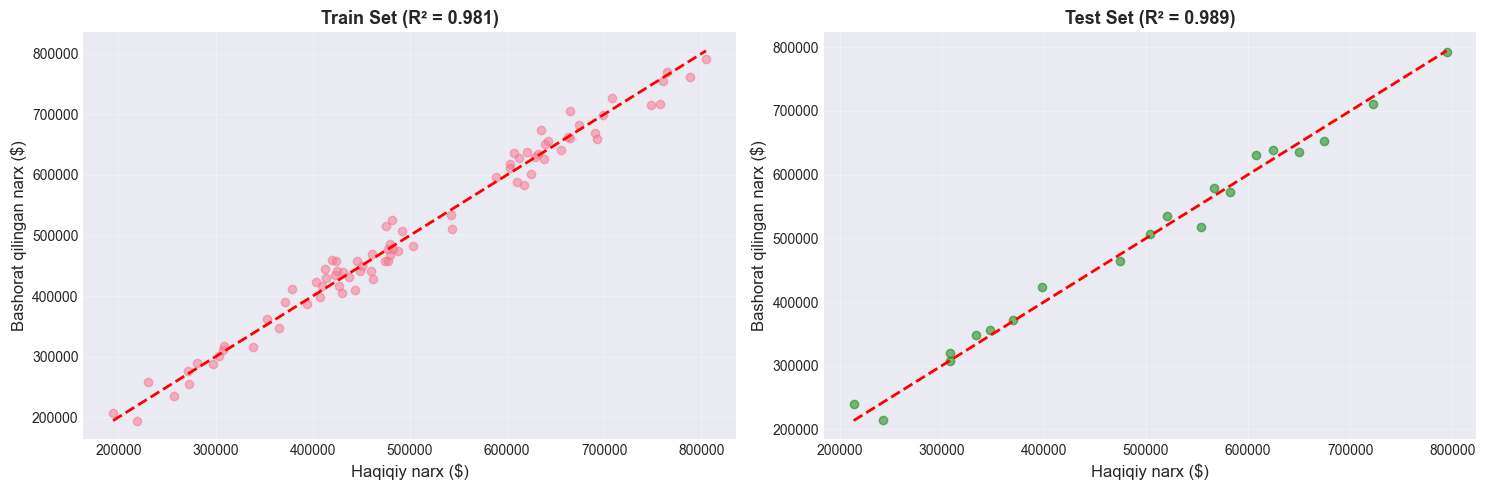

In [13]:
# Haqiqiy vs Bashorat qilingan qiymatlar
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Haqiqiy narx ($)', fontsize=12)
axes[0].set_ylabel('Bashorat qilingan narx ($)', fontsize=12)
axes[0].set_title(f'Train Set (R² = {train_r2:.3f})', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Haqiqiy narx ($)', fontsize=12)
axes[1].set_ylabel('Bashorat qilingan narx ($)', fontsize=12)
axes[1].set_title(f'Test Set (R² = {test_r2:.3f})', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

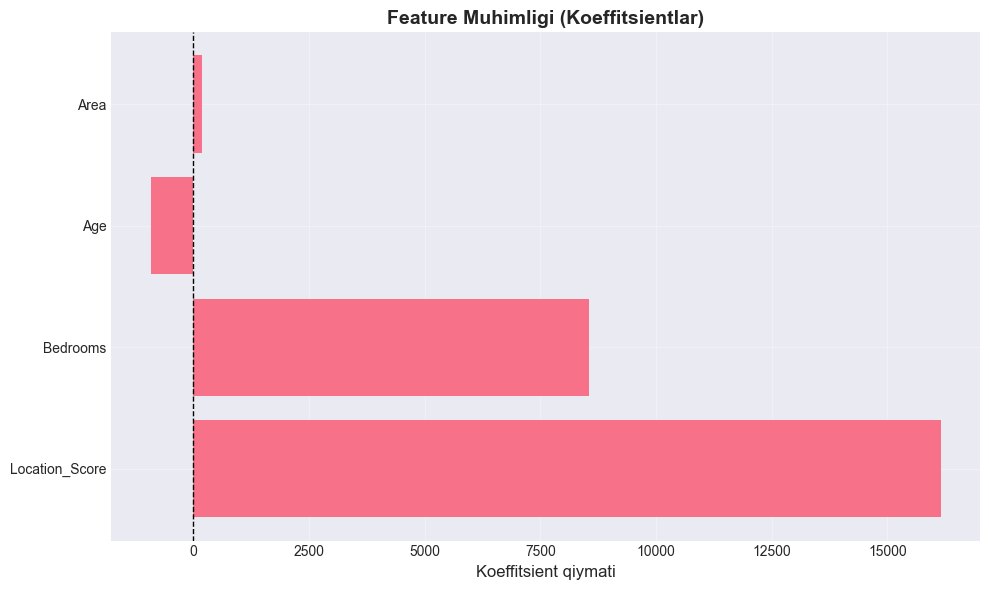

Feature muhimligi:
          Feature   Coefficient  Abs_Coefficient
3  Location_Score  16145.862972     16145.862972
1        Bedrooms   8544.750722      8544.750722
2             Age   -916.977341       916.977341
0            Area    196.853192       196.853192


In [14]:
# Feature muhimligi
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_,
    'Abs_Coefficient': np.abs(mlr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Koeffitsient qiymati', fontsize=12)
plt.title('Feature Muhimligi (Koeffitsientlar)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Feature muhimligi:")
print(feature_importance)

---

# 2️⃣ Polynomial Regression (Ko'phadli Regressiya)

## 📖 Nazariya

Polynomial Regression - bu Linear Regression ning kengaytmasi. Bu usul **nochiziqli munosabatlarni** modellash uchun ishlatiladi.

### 📐 Matematika

**2-darajali polinom** (Quadratic):
$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$$

**3-darajali polinom** (Cubic):
$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \epsilon$$

**n-darajali polinom**:
$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + ... + \beta_n x^n + \epsilon$$

### ⚠️ Muhim:
- **Underfitting**: Degree juda past bo'lsa
- **Overfitting**: Degree juda yuqori bo'lsa
- **Optimal degree**: Ma'lumotlarga mos kelishi kerak

## 💡 Misol: Polynomial Regression

Harorat va muzqaymoq sotuvlari o'rtasidagi nochiziqli munosabat.

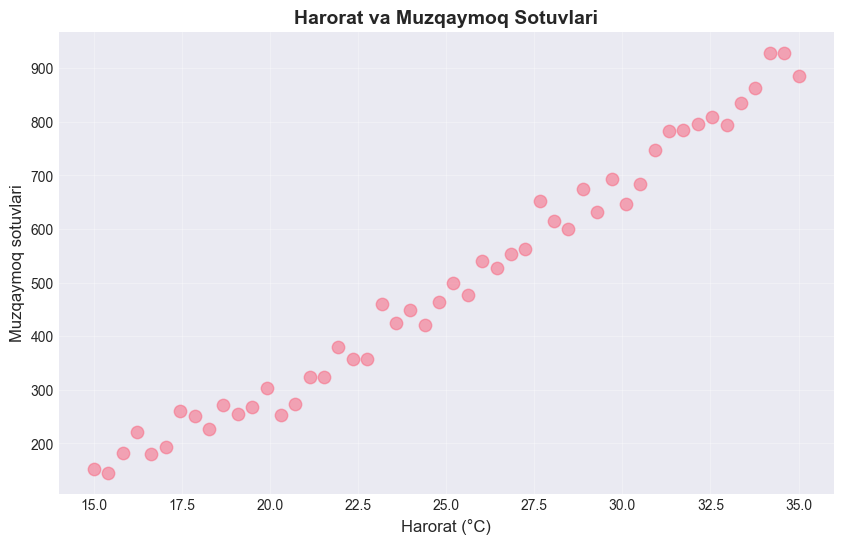

In [15]:
# Nochiziqli ma'lumotlar yaratish
np.random.seed(42)
temperature = np.linspace(15, 35, 50)
ice_cream_sales = (
    -200 + 
    15 * temperature + 
    0.5 * temperature**2 + 
    np.random.normal(0, 30, 50)
)

# Vizualizatsiya
plt.figure(figsize=(10, 6))
plt.scatter(temperature, ice_cream_sales, alpha=0.6, s=80)
plt.xlabel('Harorat (°C)', fontsize=12)
plt.ylabel('Muzqaymoq sotuvlari', fontsize=12)
plt.title('Harorat va Muzqaymoq Sotuvlari', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

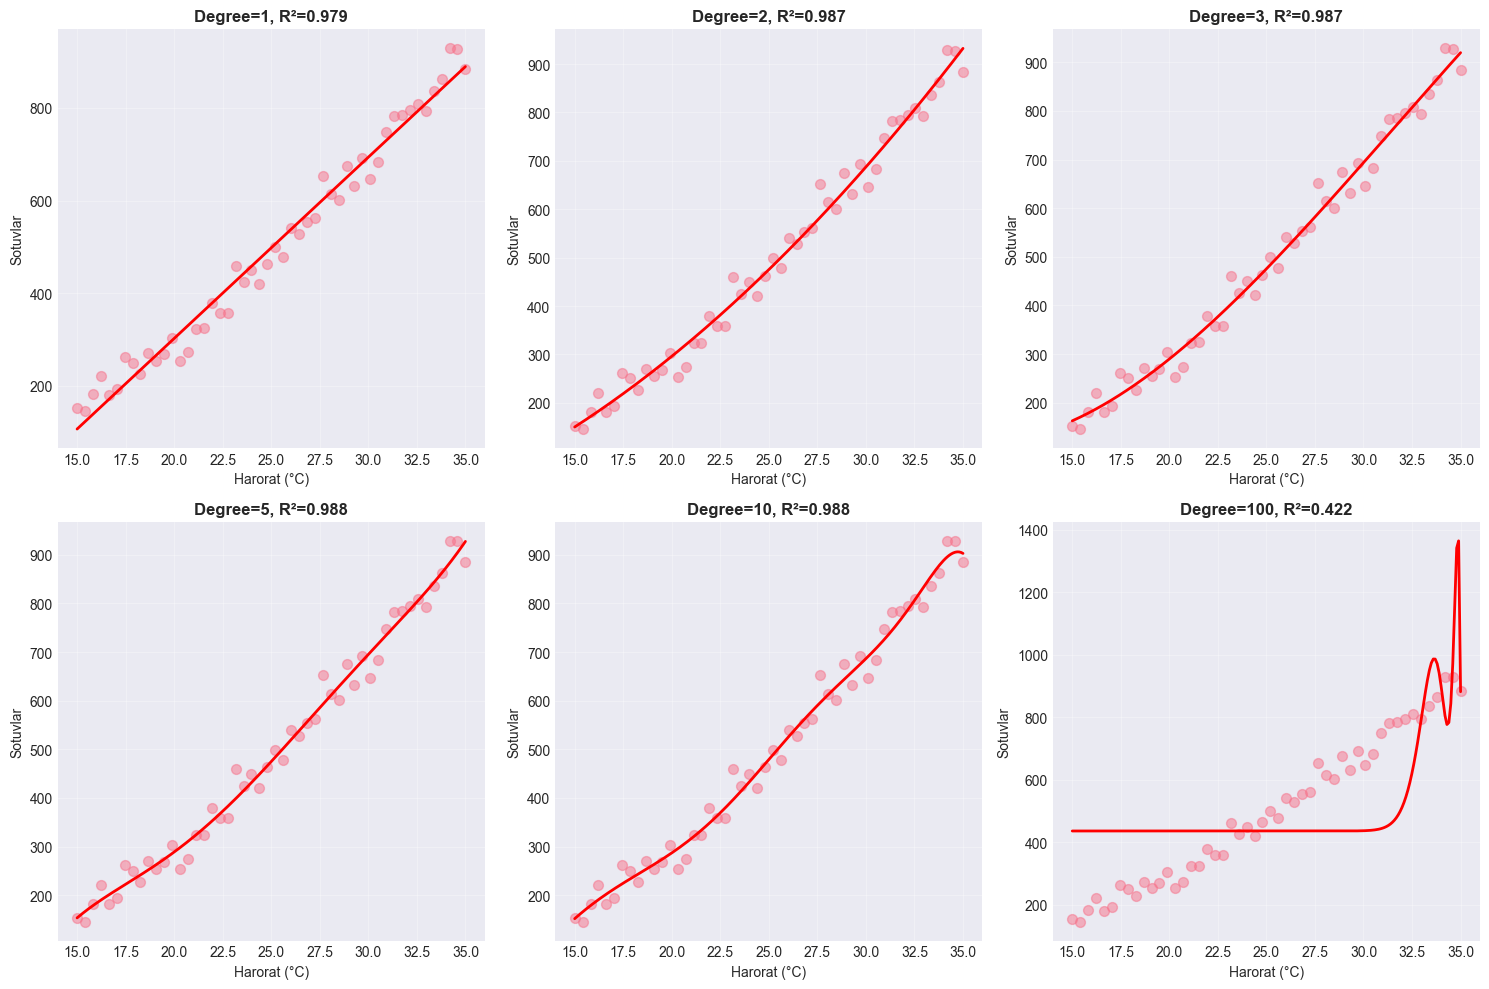

In [24]:
# Reshape
X_temp = temperature.reshape(-1, 1)
y_sales = ice_cream_sales

# Turli darajadagi polinomlarni sinab ko'rish
degrees = [1, 2, 3, 5, 10, 100]
plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees, 1):
    # Polynomial features yaratish
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X_temp)
    
    # Model
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y_sales)
    
    # Bashorat
    X_line = np.linspace(15, 35, 200).reshape(-1, 1)
    X_line_poly = poly_features.transform(X_line)
    y_line = poly_model.predict(X_line_poly)
    
    # R² score
    r2 = r2_score(y_sales, poly_model.predict(X_poly))
    
    # Plot
    plt.subplot(2, 3, i)
    plt.scatter(temperature, ice_cream_sales, alpha=0.5, s=50)
    plt.plot(X_line, y_line, 'r-', linewidth=2)
    plt.xlabel('Harorat (°C)')
    plt.ylabel('Sotuvlar')
    plt.title(f'Degree={degree}, R²={r2:.3f}', fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

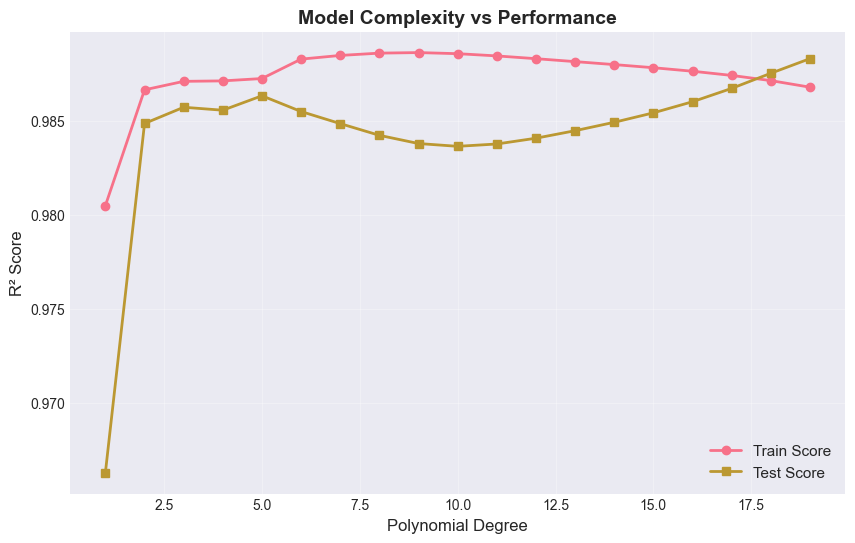

Eng yaxshi polynomial degree: 19
Test R² score: 0.9883


In [27]:
# Optimal degree topish (Cross-validation bilan)
X_train_temp, X_test_temp, y_train_sales, y_test_sales = train_test_split(
    X_temp, y_sales, test_size=0.2, random_state=42
)

train_scores = []
test_scores = []
degrees_range = range(1, 20)

for degree in degrees_range:
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train_temp)
    X_test_poly = poly_features.transform(X_test_temp)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_sales)
    
    train_scores.append(model.score(X_train_poly, y_train_sales))
    test_scores.append(model.score(X_test_poly, y_test_sales))

# Vizualizatsiya
plt.figure(figsize=(10, 6))
plt.plot(degrees_range, train_scores, 'o-', label='Train Score', linewidth=2)
plt.plot(degrees_range, test_scores, 's-', label='Test Score', linewidth=2)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Model Complexity vs Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Eng yaxshi degree
best_degree = degrees_range[np.argmax(test_scores)]
print(f"Eng yaxshi polynomial degree: {best_degree}")
print(f"Test R² score: {max(test_scores):.4f}")

---

# 3️⃣ Regularization: Ridge va Lasso

## 📖 Nazariya

Regularization - bu **overfitting**ni oldini olish uchun ishlatiladigan texnika. U model koeffitsientlariga jazo (penalty) qo'shadi.

### 🎯 Muammolar:
1. **Overfitting**: Model train ma'lumotlarini juda yaxshi o'rganadi, lekin yangi ma'lumotlarda yomon ishlaydi
2. **Ko'p feature'lar**: Ba'zi feature'lar keraksiz bo'lishi mumkin
3. **Multicollinearity**: Feature'lar o'rtasida yuqori korrelyatsiya

### 📐 Matematika

**Ridge Regression** (L2 Regularization):
$$Cost = MSE + \alpha \sum_{i=1}^{n} \beta_i^2$$

**Lasso Regression** (L1 Regularization):
$$Cost = MSE + \alpha \sum_{i=1}^{n} |\beta_i|$$

**ElasticNet** (L1 + L2):
$$Cost = MSE + \alpha_1 \sum_{i=1}^{n} |\beta_i| + \alpha_2 \sum_{i=1}^{n} \beta_i^2$$

Bu yerda:
- $\alpha$ - regularization kuchi (hyperparameter)
- $\beta_i$ - model koeffitsientlari

### 🔍 Farqlari:

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| **Penalty** | Kvadrat | Absolut qiymat |
| **Koeffitsientlar** | Kichik qiymatlar | Ba'zilari 0 bo'lishi mumkin |
| **Feature Selection** | Yo'q | Ha |
| **Multicollinearity** | Yaxshi ishlaydi | Kamroq yaxshi |
| **Qachon ishlatish** | Ko'p feature'lar | Feature selection kerak |

## 💡 Misol: Ridge vs Lasso Regression

In [29]:
# Ko'p feature'lar bilan ma'lumotlar yaratish
np.random.seed(42)
n_samples = 200
n_features = 20

# Random features
X_reg = np.random.randn(n_samples, n_features)

# Faqat ba'zi feature'lar muhim
true_coefficients = np.zeros(n_features)
true_coefficients[:5] = [10, -5, 8, -3, 6]  # Faqat 5 ta muhim feature

# Target yaratish
y_reg = X_reg @ true_coefficients + np.random.randn(n_samples) * 2

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scaling (Regularization uchun muhim!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

print(f"Ma'lumotlar shakli: {X_reg.shape}")
print(f"Muhim feature'lar soni: 5")
print(f"Jami feature'lar soni: {n_features}")

Ma'lumotlar shakli: (200, 20)
Muhim feature'lar soni: 5
Jami feature'lar soni: 20


In [30]:
# Turli modellarni sinab ko'rish
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Ridge (α=10.0)': Ridge(alpha=10.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'Lasso (α=1.0)': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train_reg)
    train_score = model.score(X_train_scaled, y_train_reg)
    test_score = model.score(X_test_scaled, y_test_reg)
    
    # Nolga teng bo'lmagan koeffitsientlar soni
    non_zero_coefs = np.sum(np.abs(model.coef_) > 0.01)
    
    results.append({
        'Model': name,
        'Train R²': train_score,
        'Test R²': test_score,
        'Non-zero Coefs': non_zero_coefs
    })

results_df = pd.DataFrame(results)
print("\nModellar taqqoslash:")
print(results_df.to_string(index=False))


Modellar taqqoslash:
            Model  Train R²  Test R²  Non-zero Coefs
Linear Regression  0.984250 0.988056              20
    Ridge (α=0.1)  0.984249 0.988063              20
    Ridge (α=1.0)  0.984204 0.988082              20
   Ridge (α=10.0)  0.980283 0.983947              20
    Lasso (α=0.1)  0.983729 0.988984               9
    Lasso (α=1.0)  0.961974 0.967632               5
       ElasticNet  0.840611 0.838531               9


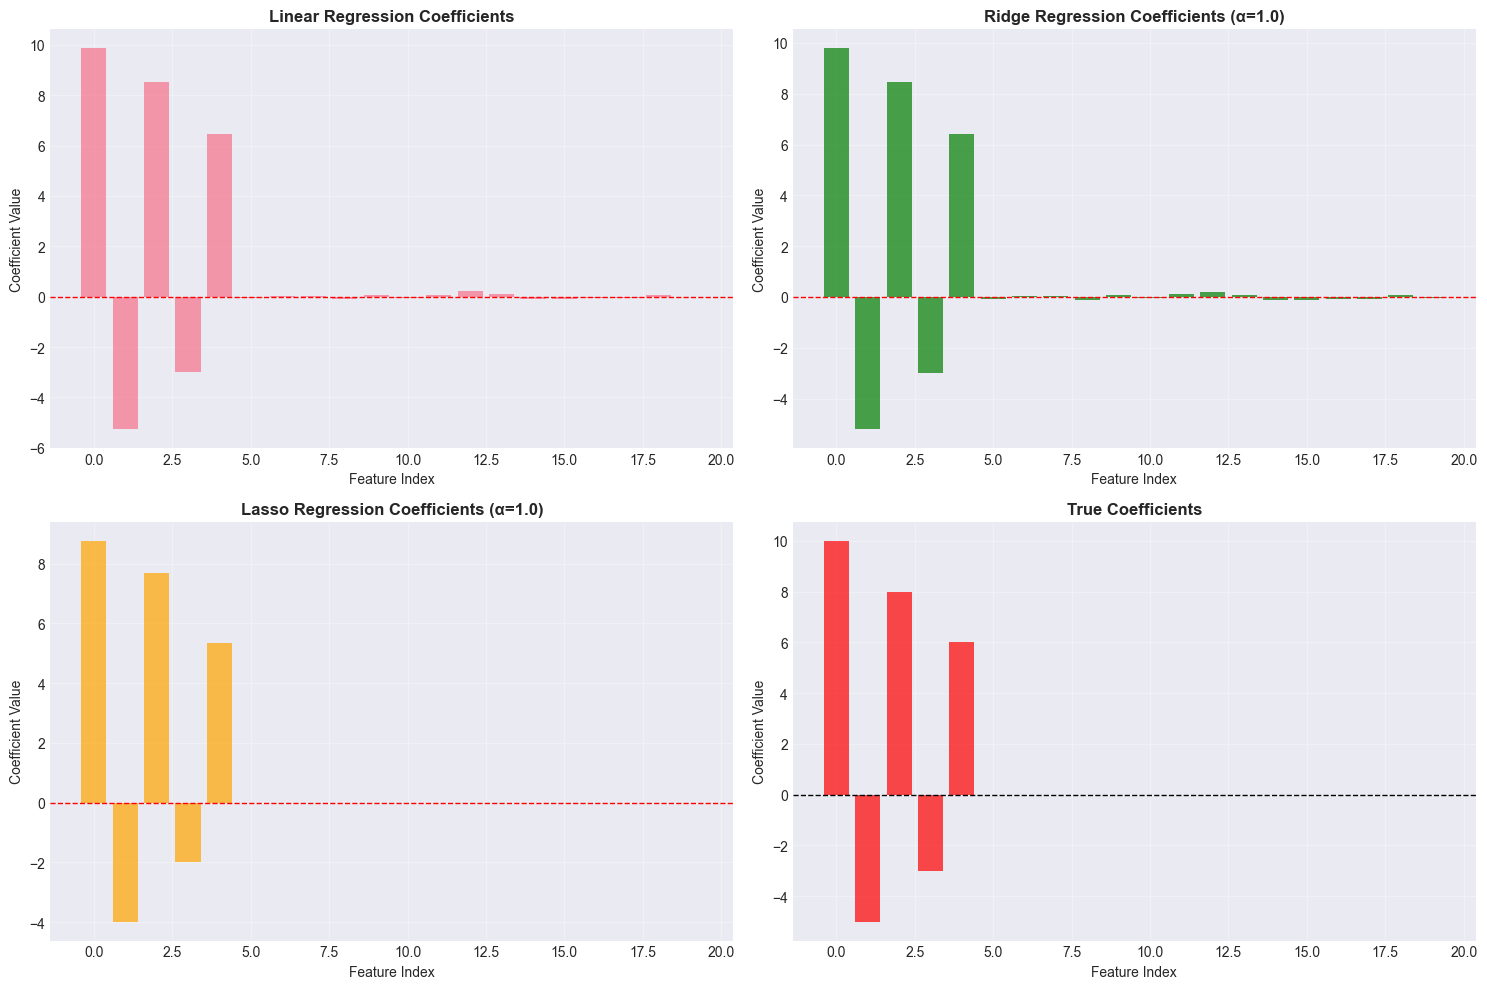

In [31]:
# Koeffitsientlarni vizualizatsiya qilish
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_reg)
axes[0, 0].bar(range(n_features), lr_model.coef_, alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Linear Regression Coefficients', fontweight='bold')
axes[0, 0].set_xlabel('Feature Index')
axes[0, 0].set_ylabel('Coefficient Value')
axes[0, 0].grid(True, alpha=0.3)

# Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train_reg)
axes[0, 1].bar(range(n_features), ridge_model.coef_, alpha=0.7, color='green')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Ridge Regression Coefficients (α=1.0)', fontweight='bold')
axes[0, 1].set_xlabel('Feature Index')
axes[0, 1].set_ylabel('Coefficient Value')
axes[0, 1].grid(True, alpha=0.3)

# Lasso
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train_reg)
axes[1, 0].bar(range(n_features), lasso_model.coef_, alpha=0.7, color='orange')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('Lasso Regression Coefficients (α=1.0)', fontweight='bold')
axes[1, 0].set_xlabel('Feature Index')
axes[1, 0].set_ylabel('Coefficient Value')
axes[1, 0].grid(True, alpha=0.3)

# Haqiqiy koeffitsientlar
axes[1, 1].bar(range(n_features), true_coefficients, alpha=0.7, color='red')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('True Coefficients', fontweight='bold')
axes[1, 1].set_xlabel('Feature Index')
axes[1, 1].set_ylabel('Coefficient Value')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

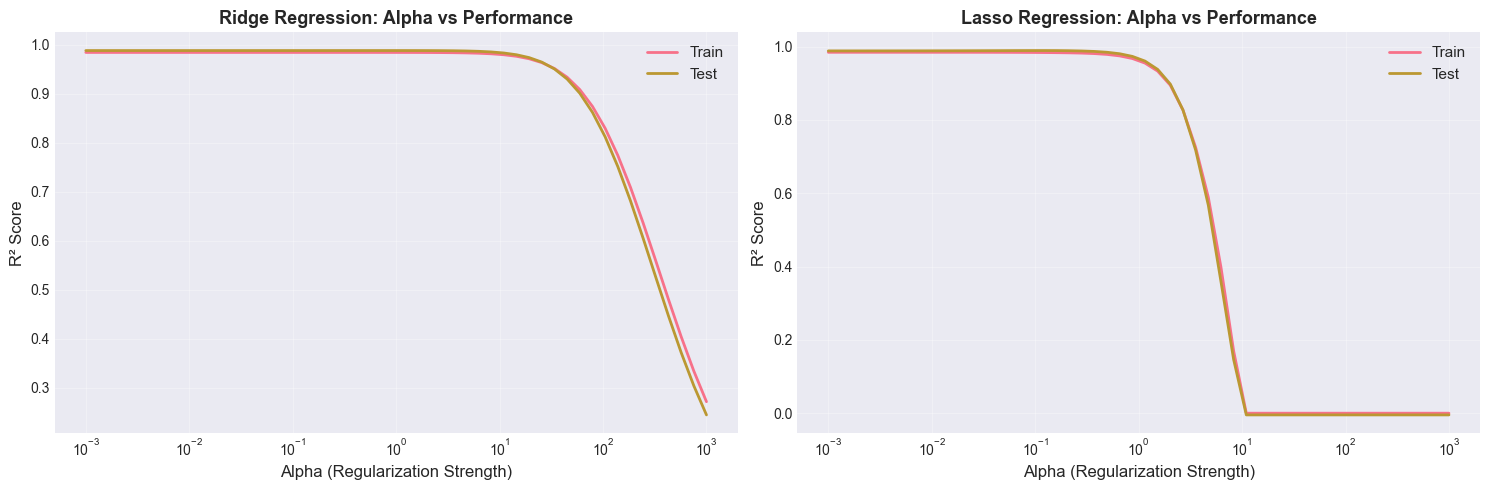

Optimal Ridge alpha: 0.6551
Optimal Ridge R²: 0.9881

Optimal Lasso alpha: 0.1207
Optimal Lasso R²: 0.9890


In [32]:
# Alpha parametrini tanlash (Hyperparameter Tuning)
alphas = np.logspace(-3, 3, 50)

ridge_train_scores = []
ridge_test_scores = []
lasso_train_scores = []
lasso_test_scores = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_reg)
    ridge_train_scores.append(ridge.score(X_train_scaled, y_train_reg))
    ridge_test_scores.append(ridge.score(X_test_scaled, y_test_reg))
    
    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_reg)
    lasso_train_scores.append(lasso.score(X_train_scaled, y_train_reg))
    lasso_test_scores.append(lasso.score(X_test_scaled, y_test_reg))

# Vizualizatsiya
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Ridge
axes[0].semilogx(alphas, ridge_train_scores, label='Train', linewidth=2)
axes[0].semilogx(alphas, ridge_test_scores, label='Test', linewidth=2)
axes[0].set_xlabel('Alpha (Regularization Strength)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Ridge Regression: Alpha vs Performance', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Lasso
axes[1].semilogx(alphas, lasso_train_scores, label='Train', linewidth=2)
axes[1].semilogx(alphas, lasso_test_scores, label='Test', linewidth=2)
axes[1].set_xlabel('Alpha (Regularization Strength)', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Lasso Regression: Alpha vs Performance', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optimal alpha
best_ridge_alpha = alphas[np.argmax(ridge_test_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_test_scores)]

print(f"Optimal Ridge alpha: {best_ridge_alpha:.4f}")
print(f"Optimal Ridge R²: {max(ridge_test_scores):.4f}")
print(f"\nOptimal Lasso alpha: {best_lasso_alpha:.4f}")
print(f"Optimal Lasso R²: {max(lasso_test_scores):.4f}")

---

# 4️⃣ Model Comparison va Best Practices

## 📊 Barcha modellarni taqqoslash

In [33]:
# Real-world dataset: California Housing
from sklearn.datasets import fetch_california_housing

# Ma'lumotlarni yuklash
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

print("California Housing Dataset:")
print(f"Namunalar soni: {X_housing.shape[0]}")
print(f"Feature'lar soni: {X_housing.shape[1]}")
print(f"\nFeature nomlari:")
print(X_housing.columns.tolist())
print(f"\nBirinchi 5 qator:")
print(X_housing.head())

California Housing Dataset:
Namunalar soni: 20640
Feature'lar soni: 8

Feature nomlari:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Birinchi 5 qator:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [35]:
# Ma'lumotlarni tayyorlash
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Scaling
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

print(f"Train set: {X_train_h.shape}")
print(f"Test set: {X_test_h.shape}")

Train set: (16512, 8)
Test set: (4128, 8)


In [36]:
# Barcha modellarni sinab ko'rish
all_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Ridge (α=10.0)': Ridge(alpha=10.0),
    'Ridge (α=100.0)': Ridge(alpha=100.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'Lasso (α=1.0)': Lasso(alpha=1.0),
    'ElasticNet (α=1.0)': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

comparison_results = []

for name, model in all_models.items():
    # O'rgatish
    model.fit(X_train_h_scaled, y_train_h)
    
    # Bashorat
    y_train_pred = model.predict(X_train_h_scaled)
    y_test_pred = model.predict(X_test_h_scaled)
    
    # Metrikalar
    comparison_results.append({
        'Model': name,
        'Train R²': r2_score(y_train_h, y_train_pred),
        'Test R²': r2_score(y_test_h, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_h, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_h, y_test_pred)),
        'Non-zero Coefs': np.sum(np.abs(model.coef_) > 0.001)
    })

comparison_df = pd.DataFrame(comparison_results)
print("\n" + "="*80)
print("BARCHA MODELLAR TAQQOSLASH")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


BARCHA MODELLAR TAQQOSLASH
             Model  Train R²   Test R²  Train RMSE  Test RMSE  Non-zero Coefs
 Linear Regression  0.612551  0.575788    0.719676   0.745581               8
     Ridge (α=1.0)  0.612551  0.575816    0.719676   0.745557               8
    Ridge (α=10.0)  0.612544  0.576060    0.719682   0.745342               8
   Ridge (α=100.0)  0.611957  0.577791    0.720227   0.743819               7
     Lasso (α=0.1)  0.497419  0.481361    0.819658   0.824396               3
     Lasso (α=1.0)  0.000000 -0.000219    1.156191   1.144856               0
ElasticNet (α=1.0)  0.208131  0.203126    1.028860   1.021876               1


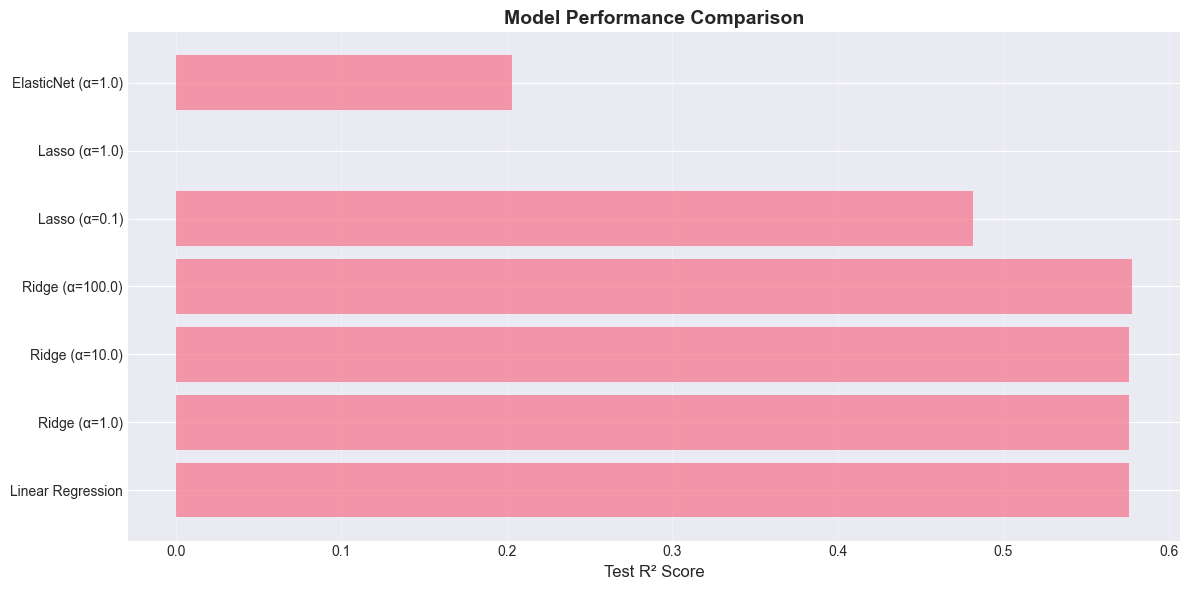

In [37]:
# Vizualizatsiya: Test R² taqqoslash
plt.figure(figsize=(12, 6))
plt.barh(comparison_df['Model'], comparison_df['Test R²'], alpha=0.7)
plt.xlabel('Test R² Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 🎓 Learning Curves

Learning curves - bu modelning train va validation performance'ini ma'lumotlar soni o'zgarishi bilan ko'rsatadi.

In [ ]:
# Learning curves funksiyasi
def plot_learning_curves(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Train score', linewidth=2)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.plot(train_sizes, val_mean, label='Validation score', linewidth=2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('R² Score', fontsize=12)
    plt.title(f'Learning Curves: {title}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Linear Regression
plot_learning_curves(LinearRegression(), X_train_h_scaled, y_train_h, 'Linear Regression')

In [ ]:
# Ridge Regression
plot_learning_curves(Ridge(alpha=10.0), X_train_h_scaled, y_train_h, 'Ridge Regression (α=10.0)')

In [ ]:
# Lasso Regression
plot_learning_curves(Lasso(alpha=0.1), X_train_h_scaled, y_train_h, 'Lasso Regression (α=0.1)')

---

# 📝 Xulosa va Tavsiyalar

## 🎯 Qaysi modelni tanlash kerak?

### Linear Regression
**Ishlatish:**
- ✅ Feature'lar kam bo'lsa
- ✅ Chiziqli munosabat bor
- ✅ Tez natija kerak
- ✅ Interpretability muhim

**Ishlatmaslik:**
- ❌ Feature'lar juda ko'p
- ❌ Multicollinearity bor
- ❌ Nochiziqli munosabat

### Polynomial Regression
**Ishlatish:**
- ✅ Nochiziqli munosabat
- ✅ Curve fitting kerak
- ✅ Feature'lar kam

**Ishlatmaslik:**
- ❌ Feature'lar ko'p (overfitting)
- ❌ Extrapolation kerak

### Ridge Regression
**Ishlatish:**
- ✅ Feature'lar ko'p
- ✅ Multicollinearity bor
- ✅ Barcha feature'lar muhim
- ✅ Overfitting muammosi

**Ishlatmaslik:**
- ❌ Feature selection kerak

### Lasso Regression
**Ishlatish:**
- ✅ Feature selection kerak
- ✅ Feature'lar ko'p
- ✅ Ba'zi feature'lar keraksiz
- ✅ Sparse model kerak

**Ishlatmaslik:**
- ❌ Barcha feature'lar muhim
- ❌ Multicollinearity yuqori

### ElasticNet
**Ishlatish:**
- ✅ Ridge va Lasso o'rtasi kerak
- ✅ Ko'p feature'lar + Feature selection
- ✅ Multicollinearity + Keraksiz feature'lar

## 💡 Best Practices

1. **Ma'lumotlarni tayyorlash:**
   - Scaling/Normalization (ayniqsa regularization uchun)
   - Missing values ni to'ldirish
   - Outliers ni tekshirish

2. **Feature Engineering:**
   - Yangi feature'lar yaratish
   - Polynomial features (ehtiyotkorlik bilan)
   - Feature selection

3. **Model Selection:**
   - Oddiydan boshlang (Linear Regression)
   - Cross-validation qiling
   - Hyperparameter tuning

4. **Validation:**
   - Train-Test split
   - K-Fold Cross-Validation
   - Learning curves ni tekshiring

5. **Metrics:**
   - R² Score
   - RMSE/MAE
   - Residual plots

## 🚀 Keyingi Qadamlar

- Decision Trees va Random Forests
- Gradient Boosting (XGBoost, LightGBM)
- Advanced Feature Engineering
- Time Series Regression
- Neural Networks for Regression

---

# 📚 Qo'shimcha Mashqlar

Endi `practical.ipynb` fayliga o'ting va amaliy mashg'ulotlarni bajaring!